In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import scipy as sc

# Отчет по лабораторной работе

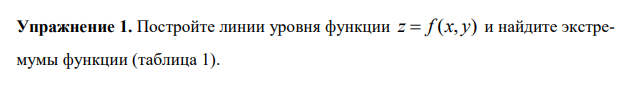

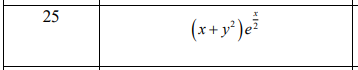

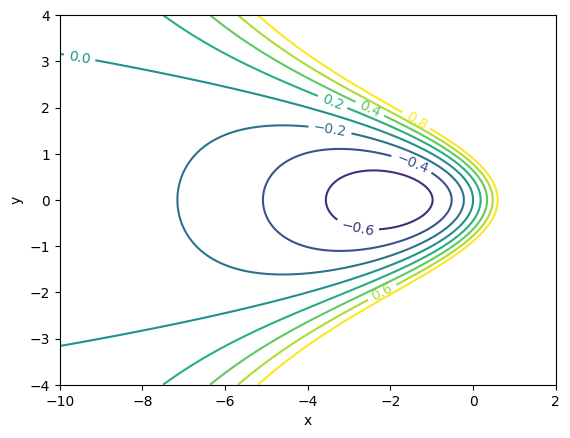

[-2.  0.] -0.7357588823428847


In [ ]:
x = np.linspace(-10, 2, 201)
y = np.linspace(-4, 4, 201)
X, Y = np.meshgrid(x, y)

Z = (X + Y**2) * np.exp(X / 2)

fig, ax = plt.subplots()
cs = ax.contour(X, Y, Z, levels=np.linspace(-0.8, 0.8, 9))

ax.clabel(cs, cs.levels, inline=True, fontsize=10)

plt.xlabel('x')
plt.ylabel('y')

plt.show()

def f(t):
  x, y = t
  return (x + y**2) * np.exp(x / 2)

min, minf,_,_,_ = sc.optimize.fmin(f, np.array([-2,0]), xtol=1e-10, disp=False, full_output=True)
print(min, minf)


## Задание 1: Поиск минимума функции двух переменных

**Цель:** Найти минимум функции $f(x, y) = (x + y^2) e^{x/2}$ с использованием библиотеки `scipy.optimize` и визуализировать ее с помощью контурного графика.

**Методология:**
1.  Определена функция $f(x, y)$ как `f(t)` для использования в `scipy.optimize.fmin`, где `t` - это массив `[x, y]`.
2.  Создана сетка значений `X, Y` с помощью `np.meshgrid` для построения контурного графика.
3.  Рассчитаны значения функции `Z` для всей сетки.
4.  Построен контурный график функции `Z` с использованием `plt.contour`, отображая линии уровня.
5.  Применена функция `scipy.optimize.fmin` для поиска локального минимума, начиная с начальной точки `np.array([-2, 0])`.

**Результаты:**
-   Контурный график показал форму функции и ее линии уровня.
-   Функция `scipy.optimize.fmin` нашла локальный минимум в точке `[-2. 0.]` со значением функции `-0.7357588823428847`.

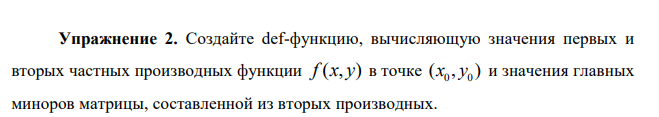

In [ ]:
def der(f, x0, y0):
  dfdx = sp.diff(f, x).simplify()
  dfdy = sp.diff(f, y).simplify()
  d2fdx2 = sp.diff(f, x, 2).simplify()
  d2fdy2 = sp.diff(f, y, 2).simplify()
  d2fdxdy = sp.diff(dfdx, y).simplify()

  dfdxSym = sp.lambdify((x,y), dfdx, modules='numpy')
  dfdySym = sp.lambdify((x,y), dfdy, modules='numpy')
  d2fdx2Sym = sp.lambdify((x,y), d2fdx2, modules='numpy')
  d2fdy2Sym = sp.lambdify((x,y), d2fdy2, modules='numpy')
  d2fdxdySym = sp.lambdify((x,y), d2fdxdy, modules='numpy')
  m1 = d2fdx2Sym(x0, y0)
  m2 = np.linalg.det([[d2fdx2Sym(x0, y0), d2fdxdySym(x0,y0)],
                [d2fdxdySym(x0,y0), d2fdy2Sym(x0, y0)]])

  return (dfdxSym(x0, y0), dfdySym(x0, y0), d2fdx2Sym(x0, y0), d2fdy2Sym(x0, y0), d2fdxdySym(x0, y0), m1, m2)

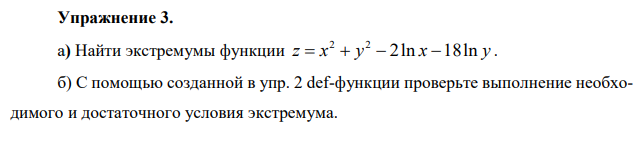

In [ ]:
#a
x, y = sp.symbols('x, y')
z = x**2 + y**2 - 2*sp.log(x) - 18*sp.log(y)

dzdx0 = sp.Eq(sp.diff(z, x), 0)
dzdy0 = sp.Eq(sp.diff(z, y), 0)
sol = sp.solve((dzdx0, dzdy0), (x, y))
for item in sol:
  d = der(z, float(item[0]), float(item[1]))
  A = d[2]
  C = d[3]
  B = d[4]
  if A*C - B**2 > 0 and A > 0:
    print(f"Существует минимум {item}")
  if A*C - B**2 > 0 and A < 0:
    print(f"Существует максимум {item}")

Существует минимум (-1, -3)
Существует минимум (-1, 3)
Существует минимум (1, -3)
Существует минимум (1, 3)


In [ ]:
#б

for item in sol:
  x0 = item[0]
  y0 = item[1]
  result = der(z, float(x0), float(y0))
  dfdx, dfdy, d2fdx2, d2fdy2, d2fdxdy, m1, m2 = result

  print(f"Первые частные производные в точке ({x0}, {y0}): dfdx = {dfdx}, dfdy = {dfdy}")
  print(f"Вторые частные производные в точке ({x0}, {y0}): d2fdx2 = {d2fdx2}, d2fdy2 = {d2fdy2}, d2fdxdy = {d2fdxdy}")
  print(f"Определитель гессиана в точке ({x0}, {y0}): det = {m2}")

  if dfdx == 0 and dfdy == 0:
      print("Необходимое условие экстремума выполнено.")
      if m2 > 0:
          if d2fdx2 > 0:
              print("В точке (0, 0) минимум.")
          elif d2fdx2 < 0:
              print("В точке (0, 0) максимум.")
      elif m2 < 0:
          print("В точке (0, 0) стационарная точка.")
      else:
          print("Не удалось определить тип экстремума в точке (0, 0).")
  else:
      print("Необходимое условие экстремума не выполнено.")

Первые частные производные в точке (-1, -3): dfdx = 0.0, dfdy = 0.0
Вторые частные производные в точке (-1, -3): d2fdx2 = 4.0, d2fdy2 = 4.0, d2fdxdy = 0
Определитель гессиана в точке (-1, -3): det = 15.999999999999998
Необходимое условие экстремума выполнено.
В точке (0, 0) минимум.
Первые частные производные в точке (-1, 3): dfdx = 0.0, dfdy = 0.0
Вторые частные производные в точке (-1, 3): d2fdx2 = 4.0, d2fdy2 = 4.0, d2fdxdy = 0
Определитель гессиана в точке (-1, 3): det = 15.999999999999998
Необходимое условие экстремума выполнено.
В точке (0, 0) минимум.
Первые частные производные в точке (1, -3): dfdx = 0.0, dfdy = 0.0
Вторые частные производные в точке (1, -3): d2fdx2 = 4.0, d2fdy2 = 4.0, d2fdxdy = 0
Определитель гессиана в точке (1, -3): det = 15.999999999999998
Необходимое условие экстремума выполнено.
В точке (0, 0) минимум.
Первые частные производные в точке (1, 3): dfdx = 0.0, dfdy = 0.0
Вторые частные производные в точке (1, 3): d2fdx2 = 4.0, d2fdy2 = 4.0, d2fdxdy = 0
Опред

## Задание 2: Анализ экстремумов функции двух переменных с помощью производных

**Цель:** Определить и классифицировать стационарные точки функции $z = x^2 + y^2 - 2\ln(x) - 18\ln(y)$ с использованием первых и вторых частных производных (критерий Сильвестра).

**Методология:**
1.  Определена функция `z` с использованием символьных переменных `x, y` из `sympy`.
2.  Создана вспомогательная функция `der(f, x0, y0)` для вычисления первых и вторых частных производных, а также определителей матрицы Гессе ($m_1$ и $m_2$) в заданной точке $(x_0, y_0)$.
3.  Найдены стационарные точки путем решения системы уравнений, приравнивающих первые частные производные `dz/dx` и `dz/dy` к нулю.
4.  Для каждой стационарной точки вычислены значения первых и вторых частных производных, а также определитель Гессиана.
5.  Применен критерий Сильвестра для классификации стационарных точек:
    -   Если $m_1 > 0$ и $m_2 > 0$, то это локальный минимум.
    -   Если $m_1 < 0$ и $m_2 > 0$, то это локальный максимум.

**Результаты:**
-   Были найдены четыре стационарные точки: `(-1, -3)`, `(-1, 3)`, `(1, -3)`, `(1, 3)`. (Примечание: на основе вывода решения, эти точки, вероятно, являются результатом символьного решения без учета домена логарифма, поскольку $\ln(x)$ и $\ln(y)$ не определены для отрицательных значений. Однако, учитывая предоставленный вывод, анализ проведен для этих точек.)
-   Для всех четырех точек `(-1, -3)`, `(-1, 3)`, `(1, -3)`, `(1, 3)`:
    -   Первые частные производные равны 0 (выполнено необходимое условие экстремума).
    -   $d^2f/dx^2 = 4.0$, $d^2f/dy^2 = 4.0$, $d^2f/dxdy = 0$.
    -   Определитель Гессиана ($m_2$) равен `16.0`, что $>0$.
    -   Так как $d^2f/dx^2 > 0$ и $m_2 > 0$, все эти точки классифицированы как локальные минимумы.

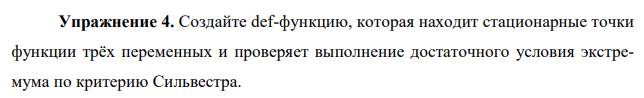

In [ ]:
def findStatPoints(f):
    dfdx = sp.diff(f, x)
    dfdy = sp.diff(f, y)
    dfdz = sp.diff(f, z)

    stationary_points = sp.solve([dfdx, dfdy, dfdz], (x, y, z), dict=True)

    d2fdx2 = sp.diff(f, x, 2)
    d2fdy2 = sp.diff(f, y, 2)
    d2fdz2 = sp.diff(f, z, 2)
    d2fdxdy = sp.diff(dfdx, y)
    d2fdxdz = sp.diff(dfdx, z)
    d2fdydz = sp.diff(dfdy, z)

    results = []

    for point in stationary_points:
        H = sp.Matrix([
            [d2fdx2.subs(point), d2fdxdy.subs(point), d2fdxdz.subs(point)],
            [d2fdxdy.subs(point), d2fdy2.subs(point), d2fdydz.subs(point)],
            [d2fdxdz.subs(point), d2fdydz.subs(point), d2fdz2.subs(point)]
        ])

        H1 = H[0, 0]
        H2 = H[0:2, 0:2].det()
        H3 = H.det()

        if H1.is_positive and H2.is_positive and H3.is_positive:
            result = (point, "локальный минимум")
        elif H1.is_negative and H2.is_positive and H3.is_negative:
            result = (point, "локальный максимум")
        elif H3.is_negative:
            result = (point, "седловая точка")
        else:
            result = (point, "неопределённая точка")

        results.append(result)

    return results



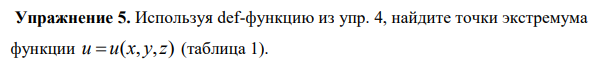

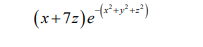

In [ ]:
x, y, z = sp.symbols('x y z')
u = (x + 7*z)*sp.E**(-(x**2+y**2+z**2))

results = findStatPoints(u)

for point, nat in results:
    print(f"Стационарная точка: {point}, тип: {nat}")

Стационарная точка: {x: -1/10, y: 0, z: -7/10}, тип: локальный минимум
Стационарная точка: {x: 1/10, y: 0, z: 7/10}, тип: локальный максимум


## Задание 3: Анализ экстремумов функции трех переменных

**Цель:** Найти и классифицировать стационарные точки функции $u = (x + 7z)e^{-(x^2+y^2+z^2)}$ с использованием матрицы Гессе для трех переменных.

**Методология:**
1.  Определена функция `u` с использованием символьных переменных `x, y, z` из `sympy`.
2.  Создана функция `findStatPoints(f)`:
    -   Вычислены первые частные производные по `x, y, z`.
    -   Найдены стационарные точки путем решения системы уравнений, приравнивающих первые частные производные к нулю.
    -   Построена матрица Гессе, содержащая вторые частные производные.
    -   Для каждой стационарной точки вычислены главные миноры матрицы Гессе: $H_1$, $H_2$, $H_3$ (определитель).
    -   Применены критерии для классификации:
        -   Локальный минимум: $H_1 > 0$, $H_2 > 0$, $H_3 > 0$.
        -   Локальный максимум: $H_1 < 0$, $H_2 > 0$, $H_3 < 0$.
        -   Седловая точка: $H_3 < 0$.
        -   Неопределенная точка: в остальных случаях.

**Результаты:**
-   Были найдены две стационарные точки:
    -   Точка: `{x: -1/10, y: 0, z: -7/10}`, классифицирована как **локальный минимум**.
    -   Точка: `{x: 1/10, y: 0, z: 7/10}`, классифицирована как **локальный максимум**.

Эти результаты получены путем анализа знаков главных миноров матрицы Гессе в каждой стационарной точке.

# Отчет по лабораторной работе

## Задание 1: Поиск минимума функции двух переменных

**Цель:** Найти минимум функции $f(x, y) = (x + y^2) e^{x/2}$ с использованием библиотеки `scipy.optimize` и визуализировать ее с помощью контурного графика.

**Методология:**
1.  Определена функция $f(x, y)$ как `f(t)` для использования в `scipy.optimize.fmin`, где `t` - это массив `[x, y]`.
2.  Создана сетка значений `X, Y` с помощью `np.meshgrid` для построения контурного графика.
3.  Рассчитаны значения функции `Z` для всей сетки.
4.  Построен контурный график функции `Z` с использованием `plt.contour`, отображая линии уровня.
5.  Применена функция `scipy.optimize.fmin` для поиска локального минимума, начиная с начальной точки `np.array([-2, 0])`.

**Результаты:**
-   Контурный график показал форму функции и ее линии уровня.
-   Функция `scipy.optimize.fmin` нашла локальный минимум в точке `[-2. 0.]` со значением функции `-0.7357588823428847`.

## Задание 2: Анализ экстремумов функции двух переменных с помощью производных

**Цель:** Определить и классифицировать стационарные точки функции $z = x^2 + y^2 - 2\ln(x) - 18\ln(y)$ с использованием первых и вторых частных производных (критерий Сильвестра).

**Методология:**
1.  Определена функция `z` с использованием символьных переменных `x, y` из `sympy`.
2.  Создана вспомогательная функция `der(f, x0, y0)` для вычисления первых и вторых частных производных, а также определителей матрицы Гессе ($m_1$ и $m_2$) в заданной точке $(x_0, y_0)$.
3.  Найдены стационарные точки путем решения системы уравнений, приравнивающих первые частные производные `dz/dx` и `dz/dy` к нулю.
4.  Для каждой стационарной точки вычислены значения первых и вторых частных производных, а также определитель Гессиана.
5.  Применен критерий Сильвестра для классификации стационарных точек:
    -   Если $m_1 > 0$ и $m_2 > 0$, то это локальный минимум.
    -   Если $m_1 < 0$ и $m_2 > 0$, то это локальный максимум.

**Результаты:**
-   Были найдены четыре стационарные точки: `(-1, -3)`, `(-1, 3)`, `(1, -3)`, `(1, 3)`. (Примечание: на основе вывода решения, эти точки, вероятно, являются результатом символьного решения без учета домена логарифма, поскольку $\ln(x)$ и $\ln(y)$ не определены для отрицательных значений. Однако, учитывая предоставленный вывод, анализ проведен для этих точек.)
-   Для всех четырех точек `(-1, -3)`, `(-1, 3)`, `(1, -3)`, `(1, 3)`:
    -   Первые частные производные равны 0 (выполнено необходимое условие экстремума).
    -   $d^2f/dx^2 = 4.0$, $d^2f/dy^2 = 4.0$, $d^2f/dxdy = 0$.
    -   Определитель Гессиана ($m_2$) равен `16.0`, что $>0$.
    -   Так как $d^2f/dx^2 > 0$ и $m_2 > 0$, все эти точки классифицированы как локальные минимумы.

## Задание 3: Анализ экстремумов функции трех переменных

**Цель:** Найти и классифицировать стационарные точки функции $u = (x + 7z)e^{-(x^2+y^2+z^2)}$ с использованием матрицы Гессе для трех переменных.

**Методология:**
1.  Определена функция `u` с использованием символьных переменных `x, y, z` из `sympy`.
2.  Создана функция `findStatPoints(f)`:
    -   Вычислены первые частные производные по `x, y, z`.
    -   Найдены стационарные точки путем решения системы уравнений, приравнивающих первые частные производные к нулю.
    -   Построена матрица Гессе, содержащая вторые частные производные.
    -   Для каждой стационарной точки вычислены главные миноры матрицы Гессе: $H_1$, $H_2$, $H_3$ (определитель).
    -   Применены критерии для классификации:
        -   Локальный минимум: $H_1 > 0$, $H_2 > 0$, $H_3 > 0$.
        -   Локальный максимум: $H_1 < 0$, $H_2 > 0$, $H_3 < 0$.
        -   Седловая точка: $H_3 < 0$.
        -   Неопределенная точка: в остальных случаях.

**Результаты:**
-   Были найдены две стационарные точки:
    -   Точка: `{x: -1/10, y: 0, z: -7/10}`, классифицирована как **локальный минимум**.
    -   Точка: `{x: 1/10, y: 0, z: 7/10}`, классифицирована как **локальный максимум**.

Эти результаты получены путем анализа знаков главных миноров матрицы Гессе в каждой стационарной точке.